# Experiment 1 — Place Cell Characterisation

**RQ1** — Does unsupervised visual clustering produce population representations with biologically plausible spatial statistics?

---

## Environment

**LM8** — open octagonal enclosure with 8 visually distinct landmarks (one per vertex).

## K Sweep

`K ∈ {50, 250, 500, 750}` — population size is the primary independent variable.

10 independent trials per K provide statistical stability; trial index is not a reported independent variable.

## Metrics (minimal defensible set)

| Metric | Description |
|---|---|
| Field size (m²) | Mean area where a cell's activation exceeds τ = 0.20 of its own peak |
| Lifetime sparseness | Rolls–Treves ratio: (mean)² / mean(squared), averaged over cells |
| Spatial information (bits) | Skaggs measure under uniform occupancy, averaged over cells with non-zero mean firing |

Coverage, population sparseness, and participation ratio are **not** reported in Experiment 1.

## Expected Trends (sanity check)

| Metric | Expected trend with increasing K |
|---|---|
| Field size | Decreases monotonically |
| Lifetime sparseness | Decreases monotonically |
| Spatial information | Increases monotonically |

---
## Metric Definitions

### Field Size  ($A_F$, threshold $\tau = 0.20$)

For each cell $i$ the **active set** is all test positions where its unnormalised RBF activation exceeds 20 % of that cell's peak:

$$\mathcal{F}_i = \left\{ n : a_i(n) > \tau \cdot \max_m a_i(m) \right\}$$

Field size = (fraction of test positions in $\mathcal{F}_i$) × convex-hull area of all test positions (m²), averaged over cells.

### Lifetime Sparseness  ($a_L$, Rolls & Treves 1990)

For each cell $i$, sparseness over the $N$ test positions:

$$a_L(i) = \frac{\left(\frac{1}{N}\sum_n r_{in}\right)^2}{\frac{1}{N}\sum_n r_{in}^2}$$

Reported as the mean over cells. Range $(0, 1]$; lower = more sparse / localised.

### Spatial Information — Skaggs Measure  ($I$)

For each cell $i$ under uniform occupancy ($p_n = 1/N$):

$$I_i = \frac{1}{N} \sum_n \frac{r_{in}}{\bar{r}_i} \log_2 \frac{r_{in}}{\bar{r}_i}$$

where $\bar{r}_i = \frac{1}{N}\sum_n r_{in}$.  Zero-activity terms contribute 0 ($\lim_{x \to 0} x \log x = 0$).  Reported as the mean over cells with non-zero mean activation (bits).

---
## Configuration

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import os
os.chdir('../..')  # set working directory to project root

import warnings
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.spatial import ConvexHull

plt.style.use('default')
mpl.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : 'white',
    'savefig.facecolor': 'white',
    'text.color'       : 'black',
    'axes.labelcolor'  : 'black',
    'xtick.color'      : 'black',
    'ytick.color'      : 'black',
    'axes.edgecolor'   : 'black',
})

from realm_tools.experiment_lib.loggers import PovDataset, combine_pov_observations
from realm_tools.place_cell_lib import fit_gmm

# ── Sweep parameters ────────────────────────────────────────────────────────
METHOD     = 'gmm'
K_VALUES   = [50, 250, 500, 750]   # primary independent variable
N_TRIALS   = 10                    # trials per K for statistical stability
FIELD_TAU  = 0.20                  # activation threshold as fraction of cell peak
REG_COVAR  = 1e-3                  # GMM covariance regularisation
TRAIN_FRAC = 0.50

# N_COMBINE = 8: collapse all 8 headings at each location into a single datapoint
# (theta and landmark_azimuths become NaN); matches the clustering pipeline
N_COMBINE  = 8

# ── Visualization ────────────────────────────────────────────────────────────
# Best N_VIZ_CELLS cells (smallest field size) from a dedicated K=750 fit
N_VIZ_CELLS = 16

# ── Environment ─────────────────────────────────────────────────────────────
MAZE      = 'lm8'
DATA_PATH = 'data/vpce/collect_data/lm8'
MAZE_XML  = 'simulation/worlds/environments/vpce/circ_lm8.xml'

SAVE_DIR = 'analysis/experiment_1_place_cell_characterization/figures'
os.makedirs(SAVE_DIR, exist_ok=True)

def savefig(filename):
    path = os.path.join(SAVE_DIR, filename)
    plt.savefig(path, dpi=150, bbox_inches='tight', facecolor='white')
    print(f'Saved → {path}')

---
## Load Habituation Dataset

In [2]:
ds       = PovDataset.load_dataset(DATA_PATH)
combined = combine_pov_observations(ds, N_COMBINE)

features = np.array(combined['multimodal_features'])
poses    = np.stack([combined['x'], combined['y'], combined['theta']], axis=1)

print(f'Maze         : {MAZE}')
print(f'N_COMBINE    : {N_COMBINE}  (all 8 headings collapsed per location)')
print(f'Observations : {features.shape[0]}')
print(f'Feature dim  : {features.shape[1]}')
print(f'Pose shape   : {poses.shape}')

Maze         : lm8
N_COMBINE    : 8  (all 8 headings collapsed per location)
Observations : 6500
Feature dim  : 7364
Pose shape   : (6500, 3)


---
## Metric Helper Functions

All metrics operate on the **unnormalised** RBF activation matrix $\mathbf{R}$ of shape $(N_{\text{test}}, K)$, so that per-cell peaks and the field threshold are not distorted by the row-normalisation applied at runtime.

In [3]:
def raw_rbf(features, centers, radii):
    """
    Unnormalised RBF activation matrix.

    Parameters
    ----------
    features : (N, D)
    centers  : (K, D)
    radii    : (K,)

    Returns
    -------
    np.ndarray  (N, K)  — values in (0, 1]
    """
    features = np.atleast_2d(np.asarray(features, dtype=np.float64))
    f_sq    = np.sum(features ** 2, axis=1, keepdims=True)   # (N, 1)
    c_sq    = np.sum(centers  ** 2, axis=1)                   # (K,)
    fc      = features @ centers.T                             # (N, K)
    dist_sq = np.maximum(f_sq - 2 * fc + c_sq, 0.0)           # (N, K)
    return np.exp(-dist_sq / (2 * radii ** 2))                 # (N, K)


def metric_field_size(R, poses, tau=0.20):
    """
    Mean place field area (m²).

    Each cell's field is the set of positions where its activation exceeds
    tau * (cell peak).  Field size = (fraction of positions in field) × hull area.
    """
    xy        = poses[:, :2]
    hull_area = ConvexHull(xy).volume   # .volume == area in 2-D
    cell_max  = R.max(axis=0)           # (K,)
    active    = R > tau * cell_max      # (N, K)  boolean
    frac      = active.mean(axis=0)     # (K,)
    return float((frac * hull_area).mean())


def metric_lifetime_sparseness(R):
    """
    Rolls-Treves lifetime sparseness, averaged over cells.
    Range (0, 1]; lower = more sparse / localised.
    """
    mu  = R.mean(axis=0)          # (K,)
    mu2 = (R ** 2).mean(axis=0)   # (K,)
    with np.errstate(invalid='ignore', divide='ignore'):
        s = np.where(mu2 > 0, mu ** 2 / mu2, 0.0)
    return float(s.mean())


def metric_spatial_information(R):
    """
    Skaggs spatial information (bits) per cell under uniform occupancy.
    Mean over cells with non-zero mean activation.

        I_i = (1/N) Σ_n (r_in / r̄_i) log₂(r_in / r̄_i)
    """
    mean_r = R.mean(axis=0)                       # (K,)
    valid  = mean_r > 0
    if not valid.any():
        return 0.0
    safe_mean = np.where(valid, mean_r, 1.0)
    ratio     = R / safe_mean                      # (N, K)
    with np.errstate(divide='ignore', invalid='ignore'):
        log_r = np.where(ratio > 0, np.log2(ratio), 0.0)
    per_cell = (ratio * log_r).mean(axis=0)        # (K,)
    return float(per_cell[valid].mean())


print('Metric functions defined.')

Metric functions defined.


---
## K-Sweep  (10 independent trials per K)

For each **(K, trial)** combination:

1. Draw a fresh **train / test split** using `seed = k_idx * 100 + trial`, where `k_idx` is the index of K in `[50, 250, 500, 750]` (0–3), **not** K itself.
2. Fit the GMM on the training split with the same seed as `random_state`.
3. Compute **unnormalised RBF activations** on the held-out test split.
4. Evaluate the three metrics and append one row to `records`.

After the loop, aggregate by K to produce **mean ± std** across the 10 trials.

In [4]:
records = []
N = len(features)

for k_idx, K in enumerate(K_VALUES):
    trial_metrics = []

    for trial in range(N_TRIALS):
        seed = k_idx * 100 + trial          # unique per (K, trial); k_idx not K
        rng  = np.random.default_rng(seed=seed)
        perm = rng.permutation(N)
        n_train   = int(N * TRAIN_FRAC)
        train_idx = perm[:n_train]
        test_idx  = perm[n_train:]

        X_train = features[train_idx]
        X_test  = features[test_idx]
        P_test  = poses[test_idx]

        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            centers, radii = fit_gmm(
                X_train,
                n_components=K,
                reg_covar=REG_COVAR,
                random_state=seed,
            )

        R = raw_rbf(X_test, centers, radii)   # (N_test, K)

        rec = {
            'K'                   : K,
            'trial'               : trial,
            'n_train'             : n_train,
            'n_test'              : len(test_idx),
            'field_size_m2'       : metric_field_size(R, P_test, tau=FIELD_TAU),
            'lifetime_sparseness' : metric_lifetime_sparseness(R),
            'spatial_info_bits'   : metric_spatial_information(R),
        }
        records.append(rec)
        trial_metrics.append(rec)

        if trial == 0:
            print(
                f'K={K:>4d}  trial={trial}  '
                f'FS={rec["field_size_m2"]:.3f} m²  '
                f'aL={rec["lifetime_sparseness"]:.4f}  '
                f'I={rec["spatial_info_bits"]:.3f} bits'
            )

    fs_vals = [r['field_size_m2']       for r in trial_metrics]
    al_vals = [r['lifetime_sparseness'] for r in trial_metrics]
    si_vals = [r['spatial_info_bits']   for r in trial_metrics]
    print(
        f'K={K:>4d}  [{N_TRIALS} trials]  '
        f'FS={np.mean(fs_vals):.3f}±{np.std(fs_vals):.3f} m²  '
        f'aL={np.mean(al_vals):.4f}±{np.std(al_vals):.4f}  '
        f'I={np.mean(si_vals):.3f}±{np.std(si_vals):.3f} bits'
    )

results = pd.DataFrame(records)

# ── Aggregate: mean ± std across trials ─────────────────────────────────────
REPORTED = ['field_size_m2', 'lifetime_sparseness', 'spatial_info_bits']
summary  = (
    results
    .groupby('K', sort=False)[REPORTED]
    .agg(['mean', 'std'])
)
summary.columns = [f'{col}_{stat}' for col, stat in summary.columns]
summary = summary.reset_index()

print(f'\nRaw records  : {len(results)} rows  (K × trial)')
print(f'Summary rows : {len(summary)} rows  (K)')

K=  50  trial=0  FS=10.697 m²  aL=0.7028  I=0.340 bits
K=  50  [10 trials]  FS=10.583±0.094 m²  aL=0.6932±0.0067  I=0.368±0.015 bits
K= 250  trial=0  FS=4.262 m²  aL=0.4797  I=0.805 bits
K= 250  [10 trials]  FS=4.186±0.081 m²  aL=0.4743±0.0056  I=0.812±0.019 bits
K= 500  trial=0  FS=1.277 m²  aL=0.2779  I=1.613 bits
K= 500  [10 trials]  FS=1.274±0.046 m²  aL=0.2791±0.0041  I=1.575±0.039 bits
K= 750  trial=0  FS=0.445 m²  aL=0.1524  I=2.554 bits
K= 750  [10 trials]  FS=0.427±0.016 m²  aL=0.1495±0.0029  I=2.550±0.031 bits

Raw records  : 40 rows  (K × trial)
Summary rows : 4 rows  (K)


---
## Results Table

Summary table reported in the paper: rows = K, columns = mean ± std for each of the three metrics.

In [5]:
fmt = {
    'field_size_m2_mean'       : '{:.4f}'.format,
    'field_size_m2_std'        : '{:.4f}'.format,
    'lifetime_sparseness_mean' : '{:.4f}'.format,
    'lifetime_sparseness_std'  : '{:.4f}'.format,
    'spatial_info_bits_mean'   : '{:.4f}'.format,
    'spatial_info_bits_std'    : '{:.4f}'.format,
}
print('── Experiment 1 Summary (mean ± std, 10 trials, LM8) ──')
print(summary.to_string(index=False, formatters=fmt))

summary_csv = os.path.join(SAVE_DIR, 'experiment_1_lm8_summary.csv')
raw_csv     = os.path.join(SAVE_DIR, 'experiment_1_lm8_raw.csv')
summary.to_csv(summary_csv, index=False)
results.to_csv(raw_csv,     index=False)
print(f'\nSaved → {summary_csv}')
print(f'Saved → {raw_csv}')

── Experiment 1 Summary (mean ± std, 10 trials, LM8) ──
  K field_size_m2_mean field_size_m2_std lifetime_sparseness_mean lifetime_sparseness_std spatial_info_bits_mean spatial_info_bits_std
 50            10.5827            0.0995                   0.6932                  0.0070                 0.3677                0.0156
250             4.1856            0.0858                   0.4743                  0.0059                 0.8120                0.0205
500             1.2738            0.0481                   0.2791                  0.0043                 1.5748                0.0412
750             0.4271            0.0167                   0.1495                  0.0030                 2.5503                0.0332

Saved → analysis/experiment_1_place_cell_characterization/figures/experiment_1_lm8_summary.csv
Saved → analysis/experiment_1_place_cell_characterization/figures/experiment_1_lm8_raw.csv


---
## Metric Plots

Each of the three metrics plotted as a function of K with mean ± std error bars (10 trials).

Saved → analysis/experiment_1_place_cell_characterization/figures/exp1_field_size.png


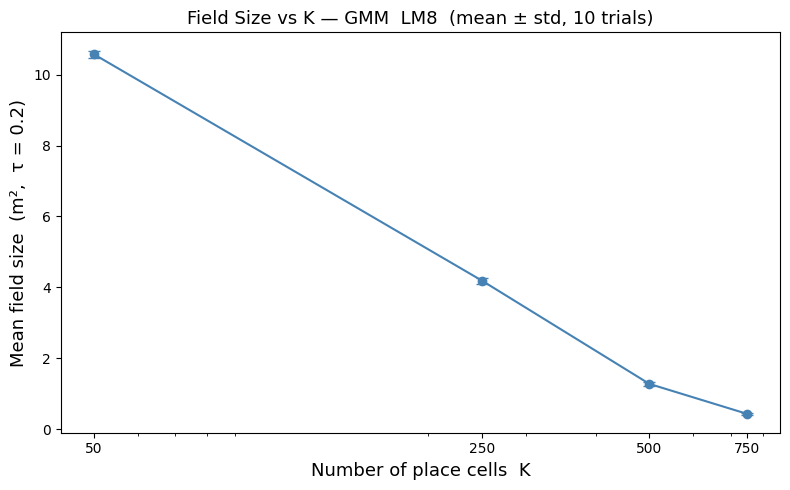

In [6]:
# ── Field Size ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(
    summary['K'], summary['field_size_m2_mean'],
    yerr=summary['field_size_m2_std'],
    marker='o', capsize=4, color='steelblue',
)
ax.set_xlabel('Number of place cells  K', fontsize=13)
ax.set_ylabel(f'Mean field size  (m²,  τ = {FIELD_TAU})', fontsize=13)
ax.set_title(f'Field Size vs K — {METHOD.upper()}  LM8  (mean ± std, {N_TRIALS} trials)', fontsize=13)
ax.set_xscale('log')
ax.set_xticks(K_VALUES)
ax.get_xaxis().set_major_formatter(mpl.ticker.ScalarFormatter())
plt.tight_layout()
savefig('exp1_field_size.png')
plt.show()

Saved → analysis/experiment_1_place_cell_characterization/figures/exp1_lifetime_sparseness.png


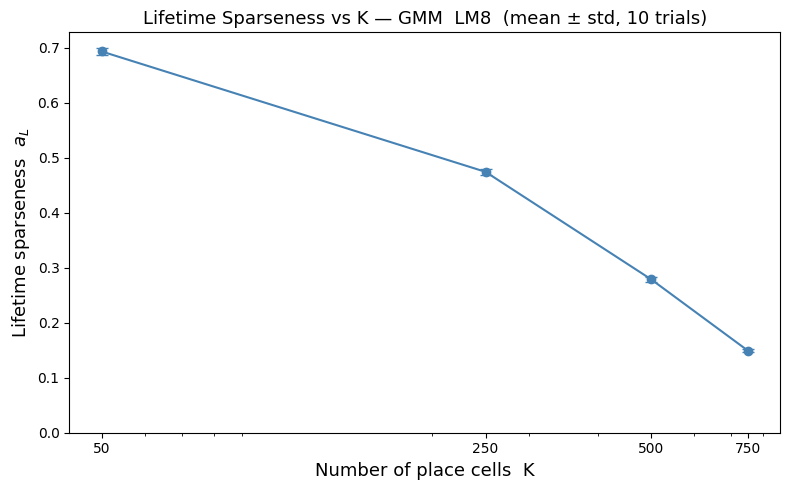

In [7]:
# ── Lifetime Sparseness ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(
    summary['K'], summary['lifetime_sparseness_mean'],
    yerr=summary['lifetime_sparseness_std'],
    marker='o', capsize=4, color='steelblue',
)
ax.set_xlabel('Number of place cells  K', fontsize=13)
ax.set_ylabel('Lifetime sparseness  $a_L$', fontsize=13)
ax.set_title(f'Lifetime Sparseness vs K — {METHOD.upper()}  LM8  (mean ± std, {N_TRIALS} trials)', fontsize=13)
ax.set_xscale('log')
ax.set_xticks(K_VALUES)
ax.get_xaxis().set_major_formatter(mpl.ticker.ScalarFormatter())
ax.set_ylim(bottom=0)
plt.tight_layout()
savefig('exp1_lifetime_sparseness.png')
plt.show()

Saved → analysis/experiment_1_place_cell_characterization/figures/exp1_spatial_information.png


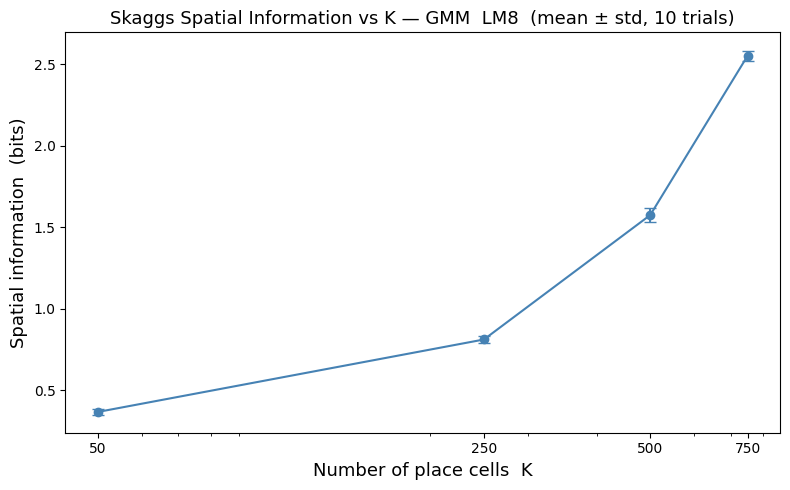

In [8]:
# ── Spatial Information ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(
    summary['K'], summary['spatial_info_bits_mean'],
    yerr=summary['spatial_info_bits_std'],
    marker='o', capsize=4, color='steelblue',
)
ax.set_xlabel('Number of place cells  K', fontsize=13)
ax.set_ylabel('Spatial information  (bits)', fontsize=13)
ax.set_title(f'Skaggs Spatial Information vs K — {METHOD.upper()}  LM8  (mean ± std, {N_TRIALS} trials)', fontsize=13)
ax.set_xscale('log')
ax.set_xticks(K_VALUES)
ax.get_xaxis().set_major_formatter(mpl.ticker.ScalarFormatter())
plt.tight_layout()
savefig('exp1_spatial_information.png')
plt.show()

---
## Summary Figure

All three metrics in a single 1 × 3 panel for inclusion in the paper.

Saved → analysis/experiment_1_place_cell_characterization/figures/experiment_1_summary.png


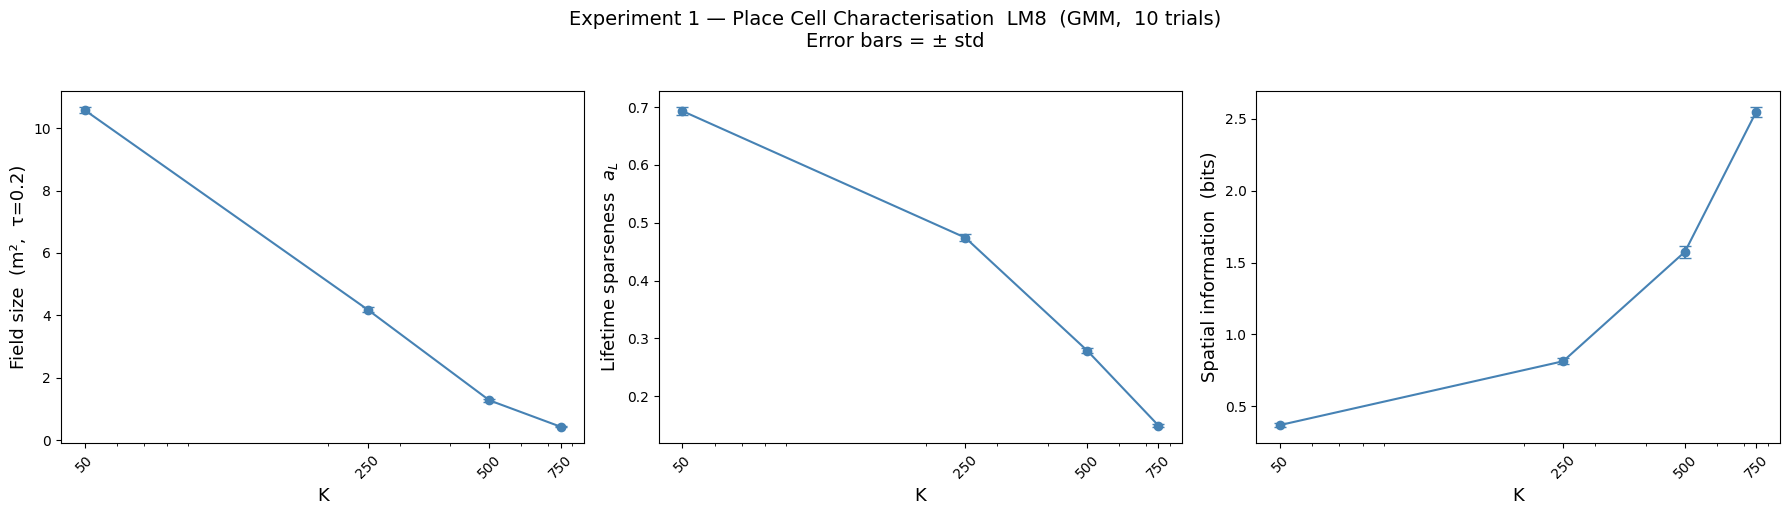

In [9]:
METRIC_SPECS = [
    ('field_size_m2',       f'Field size  (m²,  τ={FIELD_TAU})'),
    ('lifetime_sparseness', 'Lifetime sparseness  $a_L$'),
    ('spatial_info_bits',   'Spatial information  (bits)'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (col, ylabel) in zip(axes, METRIC_SPECS):
    ax.errorbar(
        summary['K'], summary[f'{col}_mean'],
        yerr=summary[f'{col}_std'],
        marker='o', markersize=6, capsize=4, color='steelblue',
    )
    ax.set_xlabel('K', fontsize=13)
    ax.set_ylabel(ylabel, fontsize=13)
    ax.set_xscale('log')
    ax.set_xticks(K_VALUES)
    ax.get_xaxis().set_major_formatter(mpl.ticker.ScalarFormatter())
    ax.tick_params(axis='x', labelrotation=45)

fig.suptitle(
    f'Experiment 1 — Place Cell Characterisation  LM8  ({METHOD.upper()},  {N_TRIALS} trials)\n'
    f'Error bars = ± std',
    fontsize=14, y=1.02,
)
plt.tight_layout()
savefig('experiment_1_summary.png')
plt.show()

---
## Place Field Heatmaps — Best Cells

A dedicated GMM fit at K = 750 is run on the full dataset (no train/test split) to give the richest possible ensemble for visualization. Per-cell field sizes are computed, and the `N_VIZ_CELLS` cells with the **smallest** field areas (most spatially localized) are selected. Each subplot shows one cell's unnormalized RBF activation projected onto the x,y plane, interpolated onto a grid and overlaid with the maze boundary.

Visualization fit  K=500,  seed=42
Selected cell indices (smallest field size): [299, 412, 468, 142, 483, 429, 189, 267, 64, 301, 367, 66, 158, 497, 41, 106]
Their field sizes (m²): [0.0025, 0.0423, 0.0971, 0.1095, 0.1095, 0.112, 0.1145, 0.127, 0.1469, 0.1543, 0.1543, 0.1842, 0.1892, 0.1917, 0.1942, 0.1967]
Saved  →  analysis/experiment_1_place_cell_characterization/figures/lm8_gmm_K500_best16_K16_activations.png


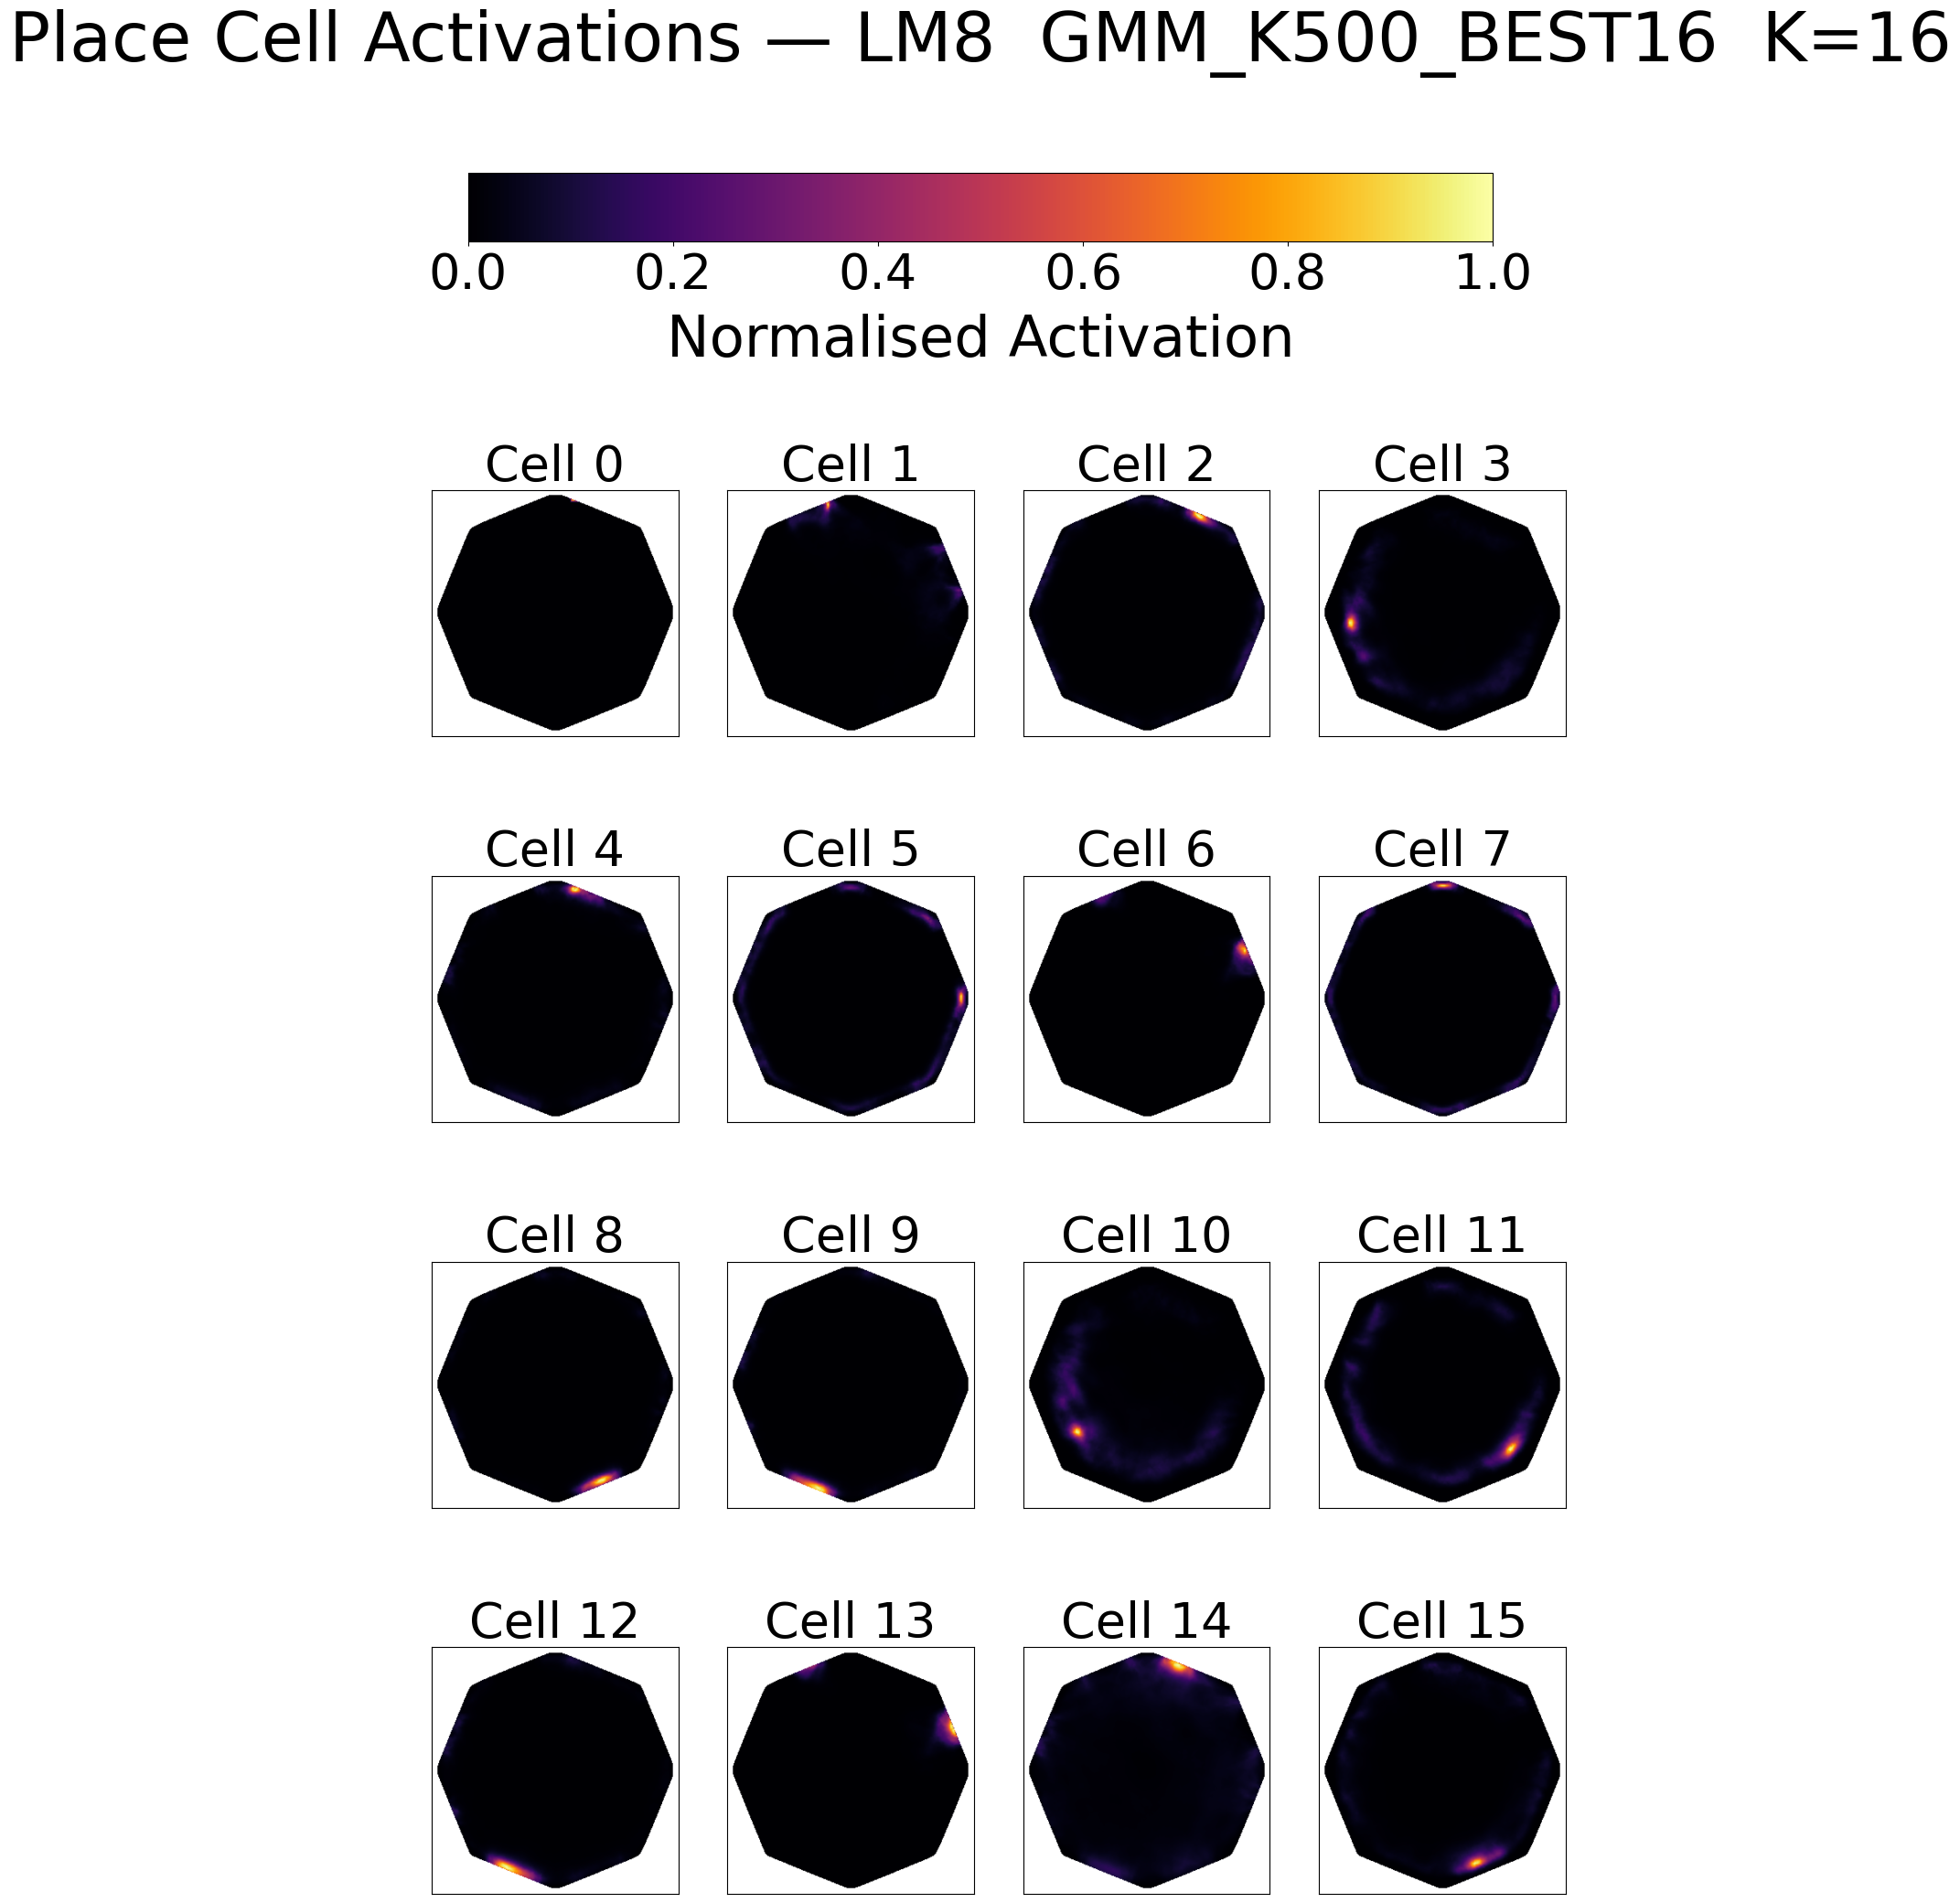

In [12]:
from realm_tools.image_lib.analysis_plots import plot_place_cell_activations

# Fit on the full dataset — visualization only, not part of the metric sweep
VIZ_K    = 500
VIZ_SEED = 42

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    viz_centers, viz_radii = fit_gmm(
        features,
        n_components=VIZ_K,
        reg_covar=REG_COVAR,
        random_state=VIZ_SEED,
    )

# Unnormalised activations on the full dataset
R_viz = raw_rbf(features, viz_centers, viz_radii)   # (N, K)

# Per-cell field size (not averaged) — same formula as metric_field_size
hull_area    = ConvexHull(poses[:, :2]).volume        # scalar
cell_max     = R_viz.max(axis=0)                      # (K,)
active_mask  = R_viz > FIELD_TAU * cell_max           # (N, K)
per_cell_fs  = active_mask.mean(axis=0) * hull_area   # (K,)

# Select the N_VIZ_CELLS cells with the smallest (most localized) field size
best_indices = np.argsort(per_cell_fs)[:N_VIZ_CELLS]
print(f'Visualization fit  K={VIZ_K},  seed={VIZ_SEED}')
print(f'Selected cell indices (smallest field size): {best_indices.tolist()}')
print(f'Their field sizes (m²): {per_cell_fs[best_indices].round(4).tolist()}')

plot_place_cell_activations(
    activations = R_viz[:, best_indices],
    poses       = poses,
    maze_xml    = MAZE_XML,
    maze        = MAZE,
    method      = f'{METHOD}_K{VIZ_K}_best{N_VIZ_CELLS}',
    save        = True,
    output_dir  = SAVE_DIR,
)